In [382]:
from pathlib import Path
import pandas as pd
from adjustText import adjust_text
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
BASE_DIR = Path.cwd().parents[1]

results = pd.read_csv(
    BASE_DIR / "FIB_SEM_optimization" / "results" / "image_quality_results.csv"
)
results_normalised = pd.read_csv(
    BASE_DIR / "FIB_SEM_optimization" / "results" / "image_quality_results_normalised.csv"
)

print(results.columns)
#print(results.head())
#print(results.describe())

Index(['sample_state', 'material', 'image_id', 'Mean', 'RMS_Contrast',
       'Entropy', 'Sharpness', 'Gradient', 'SNR', 'parameter_set',
       'voltage_kV', 'current_nA', 'detector', 'signal_out', 'mode',
       'magnification', 'notes', 'WD_mm', 'scan_speed_us', 'suction_V'],
      dtype='str')


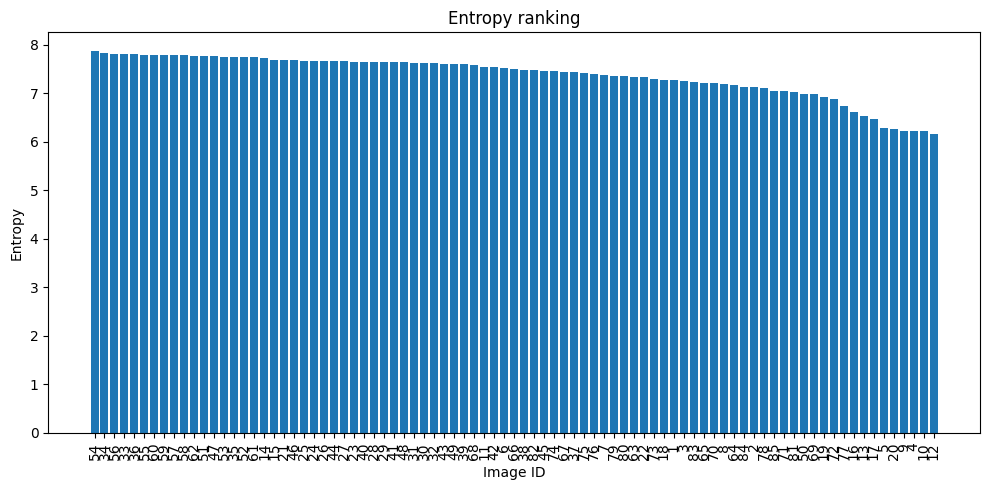

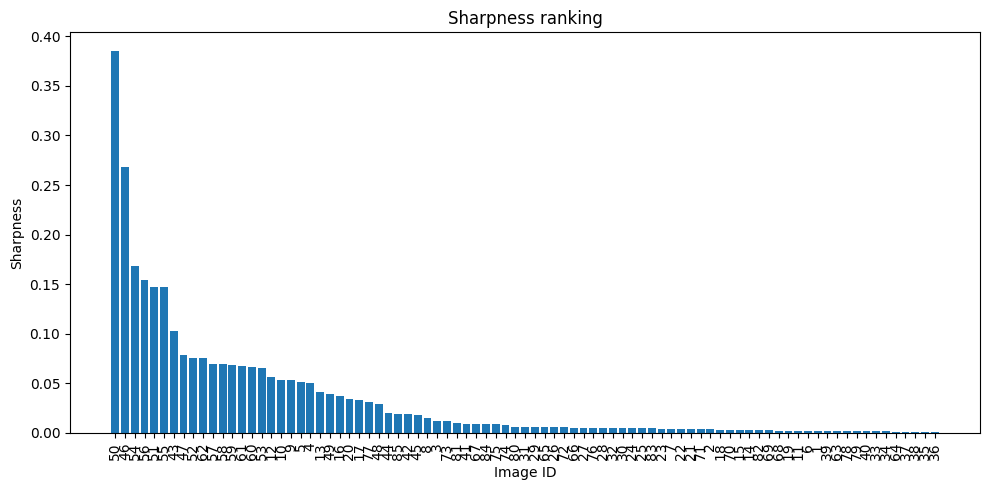

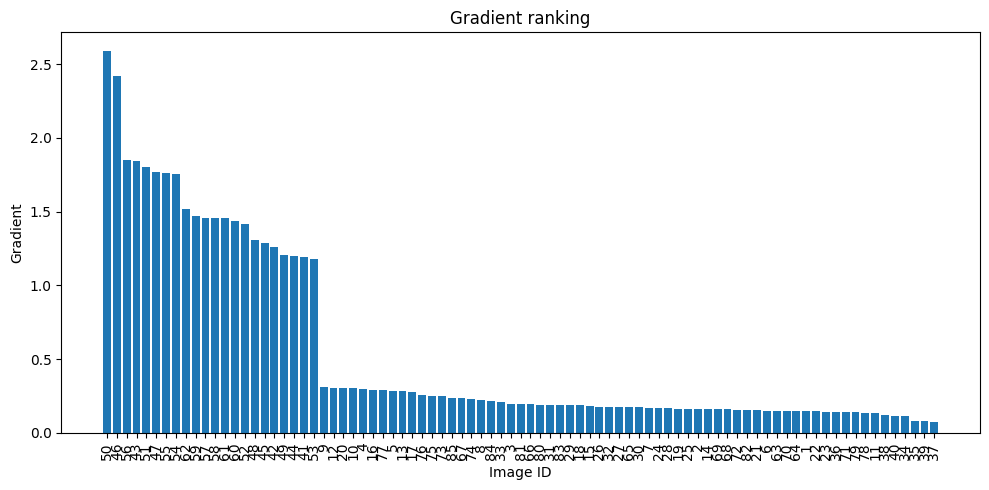

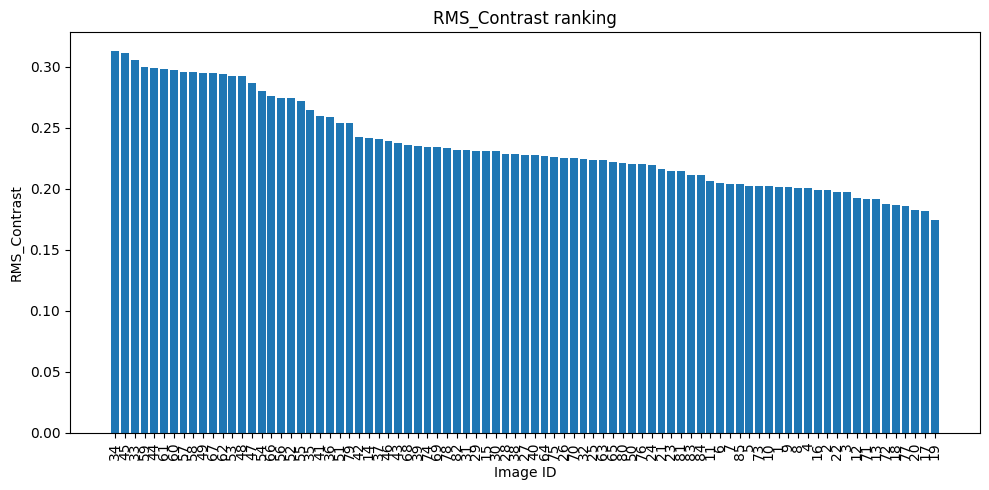

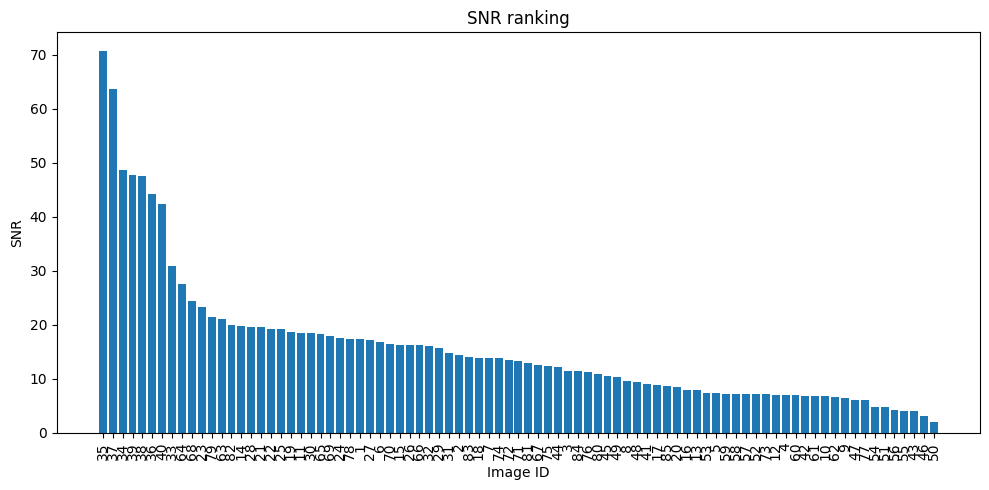

In [384]:
metrics = [
    "Entropy",
    "Sharpness",
    "Gradient",
    "RMS_Contrast",
    "SNR"
]


for metric in metrics:

    data = results_normalised.sort_values(
        by=metric,
        ascending=False
    )

    plt.figure(figsize=(10,5))

    plt.bar(
        data["image_id"].astype(str),
        data[metric]
    )

    plt.xlabel("Image ID")
    plt.ylabel(metric)
    plt.title(f"{metric} ranking")

    plt.xticks(rotation=90)

    plt.tight_layout()
    plt.show()

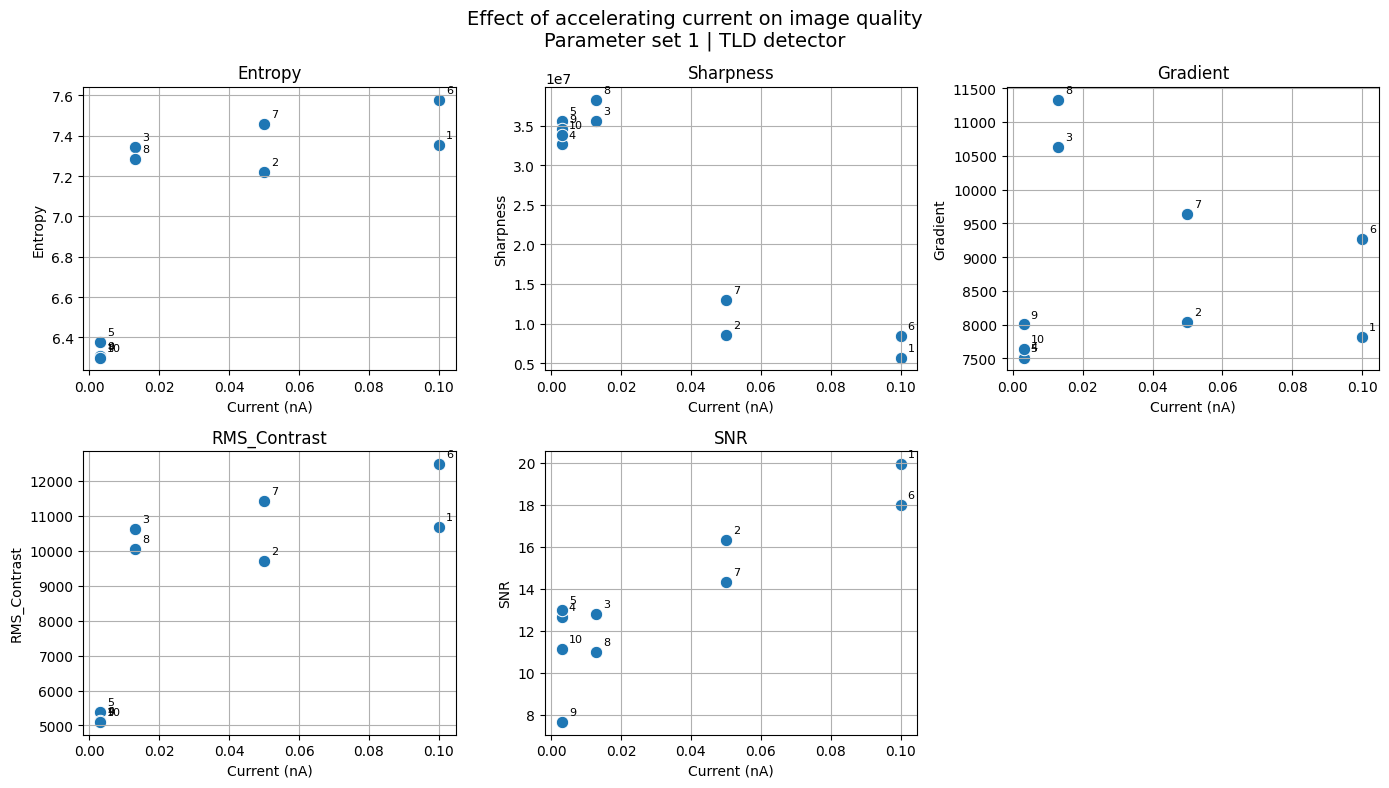

In [385]:
ps1 = results[
    (results["parameter_set"] == 1)
]


metrics = [
    "Entropy",
    "Sharpness",
    "Gradient",
    "RMS_Contrast",
    "SNR"
]


# Create 2 rows, 3 columns
fig, axes = plt.subplots(
    2,
    3,
    figsize=(14, 8),
    sharex=False
)

# Flatten axes array for easy looping
axes = axes.flatten()


for ax, metric in zip(axes, metrics):

    sns.scatterplot(
        data=ps1,
        x="current_nA",
        y=metric,
        ax=ax,
        s=80,
    )
    imageID = 1  # Set to a specific image ID to annotate points, or None to skip annotation

    if imageID is not None:
        # ===== ADD THIS PART HERE =====
        for _, row in ps1.iterrows():
            ax.annotate(
                row["image_id"],                  # label text
                (row["current_nA"], row[metric]), # point location
                xytext=(5, 5),                    # offset from point
                textcoords="offset points",
                fontsize=8
            )
        # ==============================

    ax.set_title(metric)
    ax.set_xlabel("Current (nA)")
    ax.grid(True)


# Remove unused sixth plot
axes[-1].axis("off")


fig.suptitle(
    "Effect of accelerating current on image quality\n"
    "Parameter set 1 | TLD detector",
    fontsize=14
)

plt.tight_layout()

plt.show()

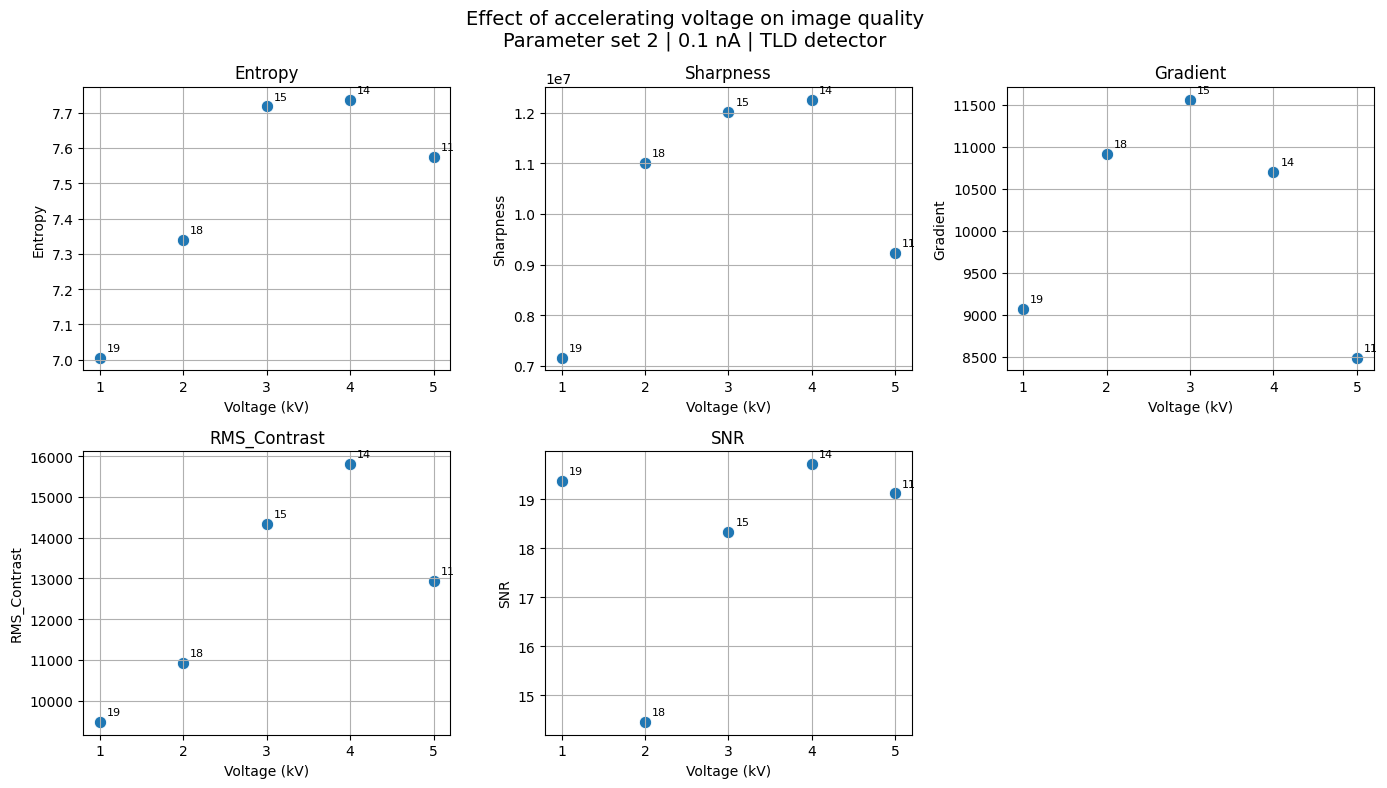

In [386]:
# Select dataset
ps2 = results[
    (results["parameter_set"] == 2) &
    (results["current_nA"] == 0.1)
]


metrics = [
    "Entropy",
    "Sharpness",
    "Gradient",
    "RMS_Contrast",
    "SNR"
]


# Create 2 rows, 3 columns
fig, axes = plt.subplots(
    2,
    3,
    figsize=(14, 8),
    sharex=False
)

# Flatten axes array for easy looping
axes = axes.flatten()


for ax, metric in zip(axes, metrics):

    sns.scatterplot(
        data=ps2,
        x="voltage_kV",
        y=metric,
        ax=ax,
        s=80
    )

    imageID = 1  # Set to a specific image ID to annotate points, or None to skip annotation
    
    if imageID is not None:
        # ===== ADD THIS PART HERE =====
        for _, row in ps2.iterrows():
            ax.annotate(
                row["image_id"],                  # label text
                (row["voltage_kV"], row[metric]), # point location
                xytext=(5, 5),                    # offset from point
                textcoords="offset points",
                fontsize=8
            )
        # ==============================

    ax.set_title(metric)
    ax.set_xlabel("Voltage (kV)")
    ax.grid(True)


# Remove unused sixth plot
axes[-1].axis("off")


fig.suptitle(
    "Effect of accelerating voltage on image quality\n"
    "Parameter set 2 | 0.1 nA | TLD detector",
    fontsize=14
)

plt.tight_layout()

plt.show()

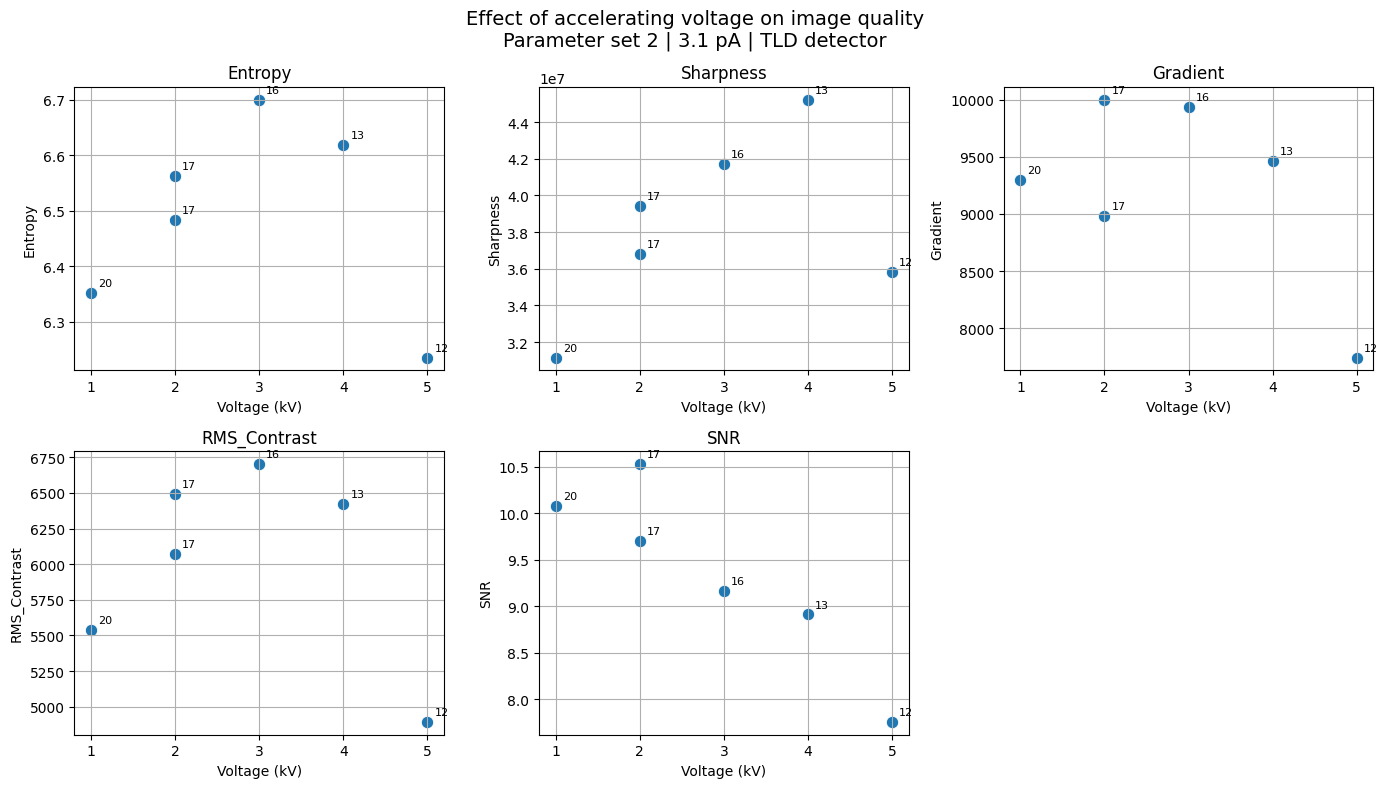

In [387]:
# Select dataset
ps2 = results[
    (results["parameter_set"] == 2) &
    (results["current_nA"] == 0.0031)
]


metrics = [
    "Entropy",
    "Sharpness",
    "Gradient",
    "RMS_Contrast",
    "SNR"
]


# Create 2 rows, 3 columns
fig, axes = plt.subplots(
    2,
    3,
    figsize=(14, 8),
    sharex=False
)

# Flatten axes array for easy looping
axes = axes.flatten()


for ax, metric in zip(axes, metrics):

    sns.scatterplot(
        data=ps2,
        x="voltage_kV",
        y=metric,
        ax=ax,
        s=80
    )

    imageID = 1  # Set to a specific image ID to annotate points, or None to skip annotation
    
    if imageID is not None:
        # ===== ADD THIS PART HERE =====
        for _, row in ps2.iterrows():
            ax.annotate(
                row["image_id"],                  # label text
                (row["voltage_kV"], row[metric]), # point location
                xytext=(5, 5),                    # offset from point
                textcoords="offset points",
                fontsize=8
            )
        # ==============================

    ax.set_title(metric)
    ax.set_xlabel("Voltage (kV)")
    ax.grid(True)


# Remove unused sixth plot
axes[-1].axis("off")


fig.suptitle(
    "Effect of accelerating voltage on image quality\n"
    "Parameter set 2 | 3.1 pA | TLD detector",
    fontsize=14
)

plt.tight_layout()

plt.show()

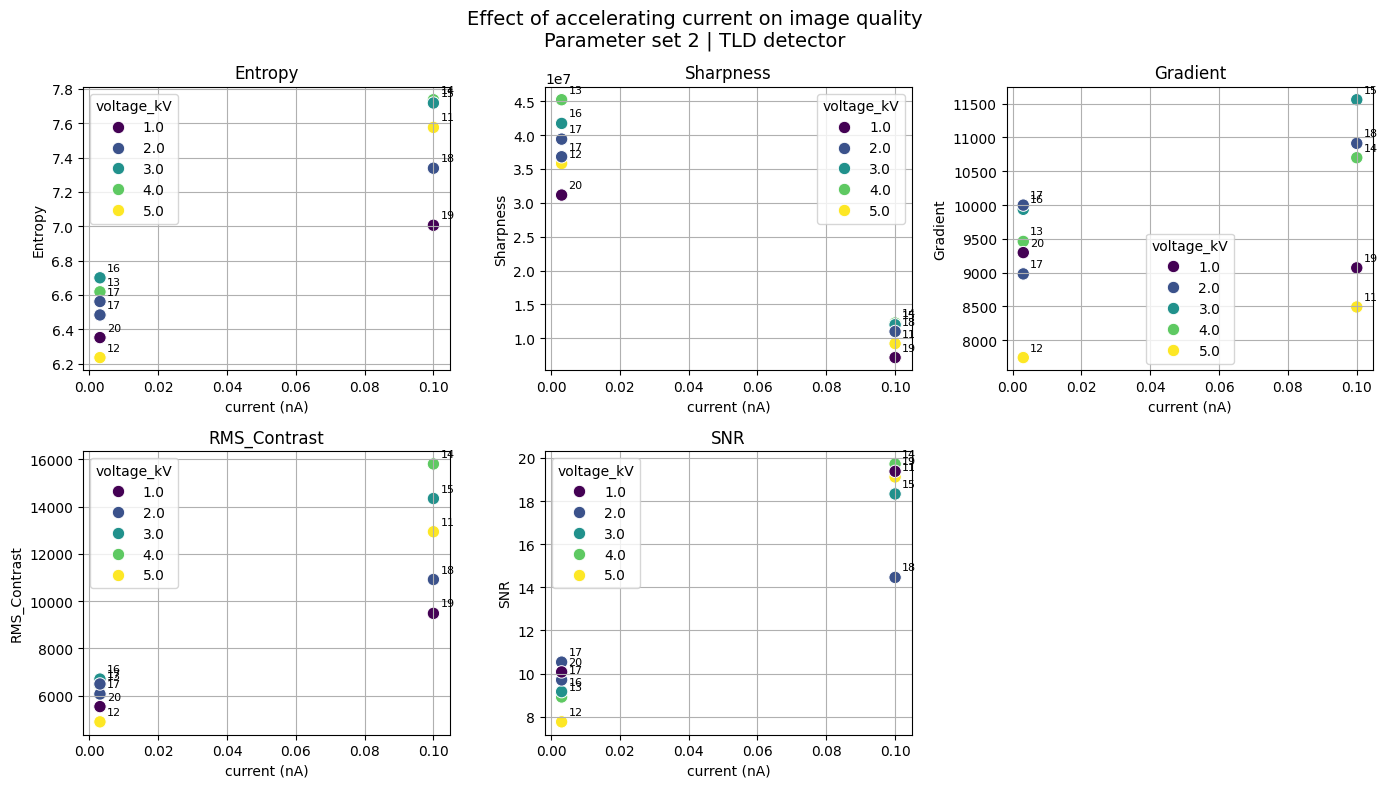

In [388]:
# Select dataset
ps2 = results[
    (results["parameter_set"] == 2)]


metrics = [
    "Entropy",
    "Sharpness",
    "Gradient",
    "RMS_Contrast",
    "SNR"
]


# Create 2 rows, 3 columns
fig, axes = plt.subplots(
    2,
    3,
    figsize=(14, 8),
    sharex=False
)

# Flatten axes array for easy looping
axes = axes.flatten()


for ax, metric in zip(axes, metrics):

    sns.scatterplot(
        data=ps2,
        x="current_nA",
        y=metric,
        ax=ax,
        s=80,
        hue="voltage_kV",
        palette="viridis"
    )

    imageID = 1  # Set to a specific image ID to annotate points, or None to skip annotation
    
    if imageID is not None:
        # ===== ADD THIS PART HERE =====
        for _, row in ps2.iterrows():
            ax.annotate(
                row["image_id"],                  # label text
                (row["current_nA"], row[metric]), # point location
                xytext=(5, 5),                    # offset from point
                textcoords="offset points",
                fontsize=8
            )
        # ==============================

    ax.set_title(metric)
    ax.set_xlabel("current (nA)")
    ax.grid(True)


# Remove unused sixth plot
axes[-1].axis("off")


fig.suptitle(
    "Effect of accelerating current on image quality\n"
    "Parameter set 2 | TLD detector",
    fontsize=14
)

plt.tight_layout()

plt.show()

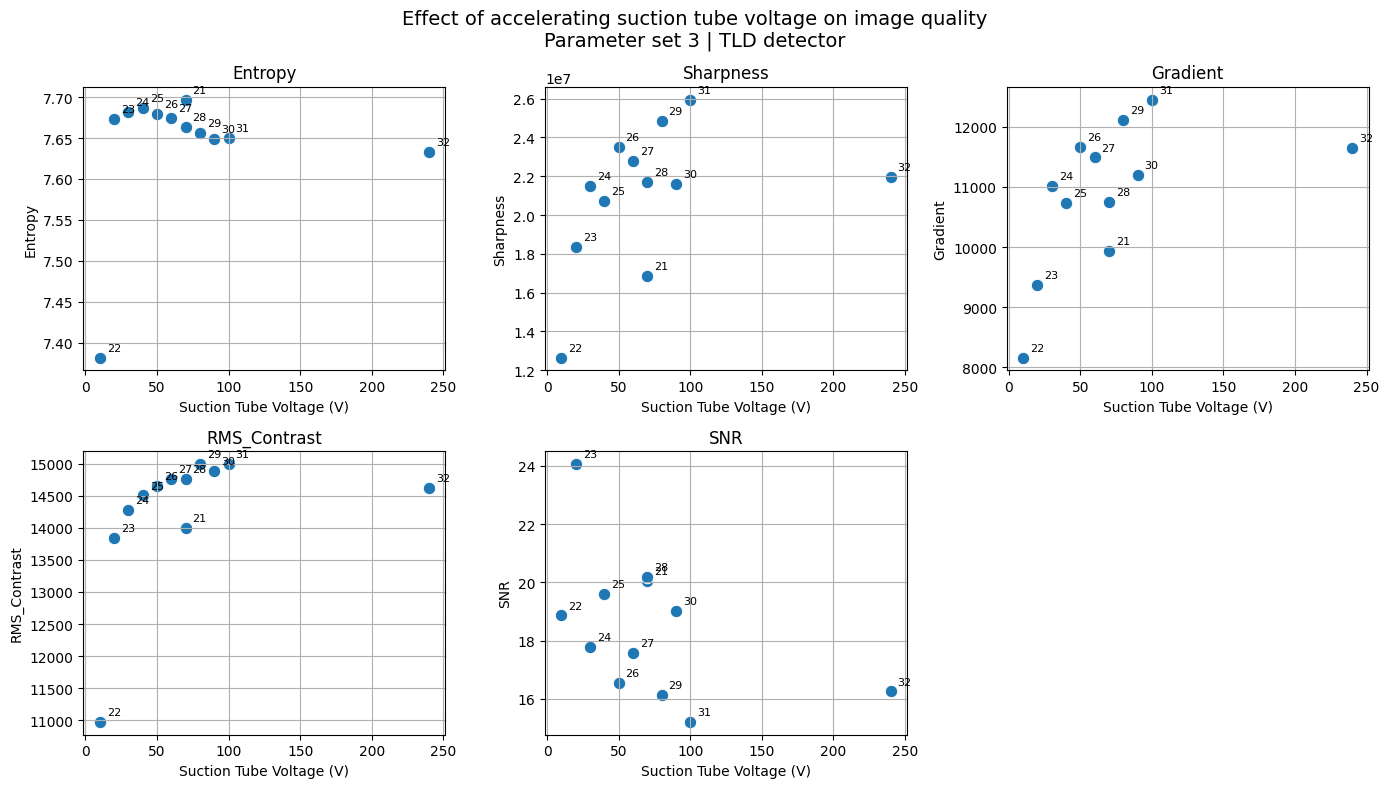

In [389]:
# Select dataset
ps3 = results[
    (results["parameter_set"] == 3)
]


metrics = [
    "Entropy",
    "Sharpness",
    "Gradient",
    "RMS_Contrast",
    "SNR"
]


# Create 2 rows, 3 columns
fig, axes = plt.subplots(
    2,
    3,
    figsize=(14, 8),
    sharex=False
)

# Flatten axes array for easy looping
axes = axes.flatten()


for ax, metric in zip(axes, metrics):

    sns.scatterplot(
        data=ps3,
        x="suction_V",
        y=metric,
        ax=ax,
        s=80
    )

    imageID = 1  # Set to a specific image ID to annotate points, or None to skip annotation

    if imageID is not None:
        # ===== ADD THIS PART HERE =====
        for _, row in ps3.iterrows():
            ax.annotate(
                row["image_id"],                  # label text
                (row["suction_V"], row[metric]), # point location
                xytext=(5, 5),                    # offset from point
                textcoords="offset points",
                fontsize=8
            )
        # ==============================

    ax.set_title(metric)
    ax.set_xlabel("Suction Tube Voltage (V)")
    ax.grid(True)


# Remove unused sixth plot
axes[-1].axis("off")


fig.suptitle(
    "Effect of accelerating suction tube voltage on image quality\n"
    "Parameter set 3 | TLD detector",
    fontsize=14
)

plt.tight_layout()

plt.show()

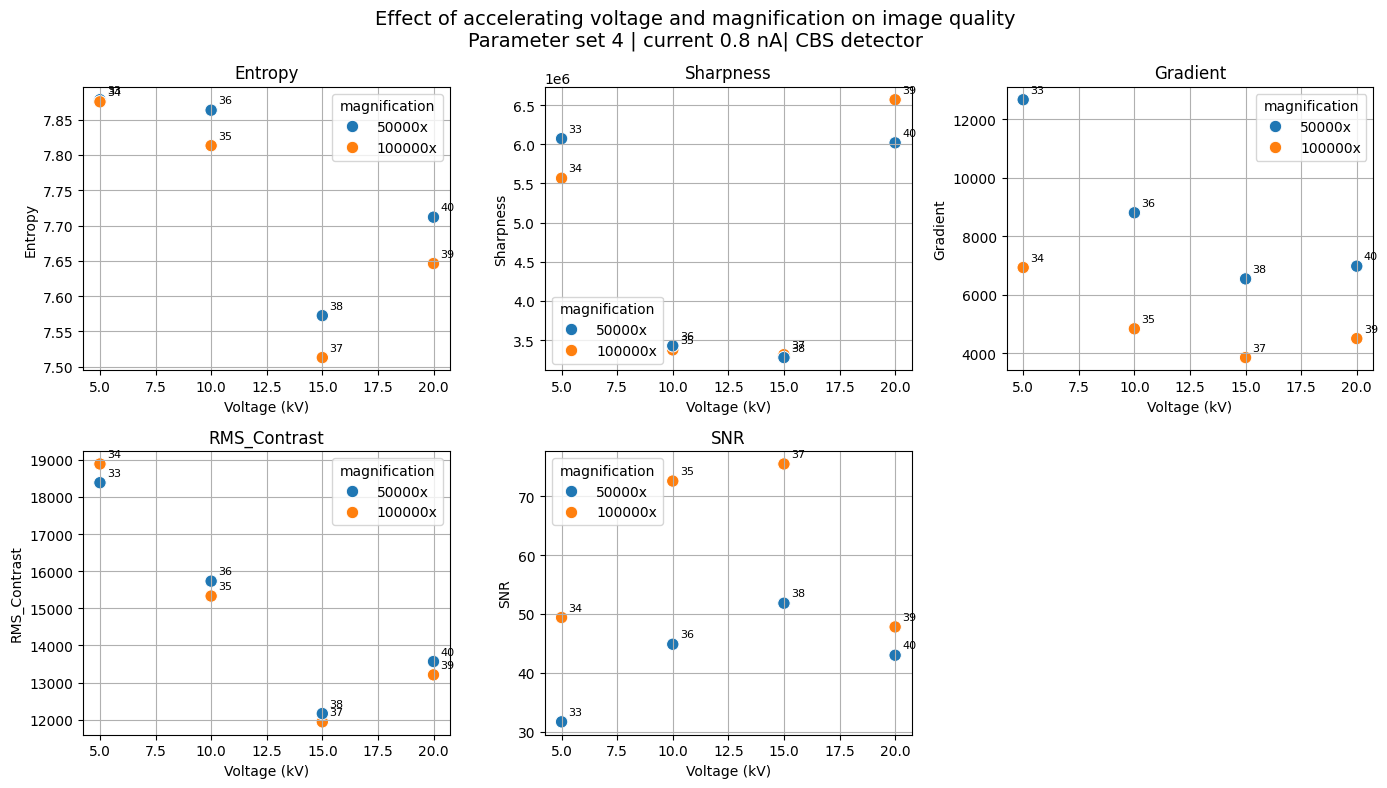

In [390]:
# Select dataset
ps4 = results[
    (results["parameter_set"] == 4)
]


metrics = [
    "Entropy",
    "Sharpness",
    "Gradient",
    "RMS_Contrast",
    "SNR"
]


# Create 2 rows, 3 columns
fig, axes = plt.subplots(
    2,
    3,
    figsize=(14, 8),
    sharex=False
)

# Flatten axes array for easy looping
axes = axes.flatten()


for ax, metric in zip(axes, metrics):

    sns.scatterplot(
        data=ps4,
        x="voltage_kV",
        y=metric,
        ax=ax,
        s=80,
        hue="magnification"
    )

    imageID = 1  # Set to a specific image ID to annotate points, or None to skip annotation

    if imageID is not None:
        # ===== ADD THIS PART HERE =====
        for _, row in ps4.iterrows():
            ax.annotate(
                row["image_id"],                  # label text
                (row["voltage_kV"], row[metric]), # point location
                xytext=(5, 5),                    # offset from point
                textcoords="offset points",
                fontsize=8
            )
        # ==============================

    ax.set_title(metric)
    ax.set_xlabel("Voltage (kV)")
    ax.grid(True)


# Remove unused sixth plot
axes[-1].axis("off")


fig.suptitle(
    "Effect of accelerating voltage and magnification on image quality\n"
    "Parameter set 4 | current 0.8 nA| CBS detector",
    fontsize=14
)

plt.tight_layout()

plt.show()

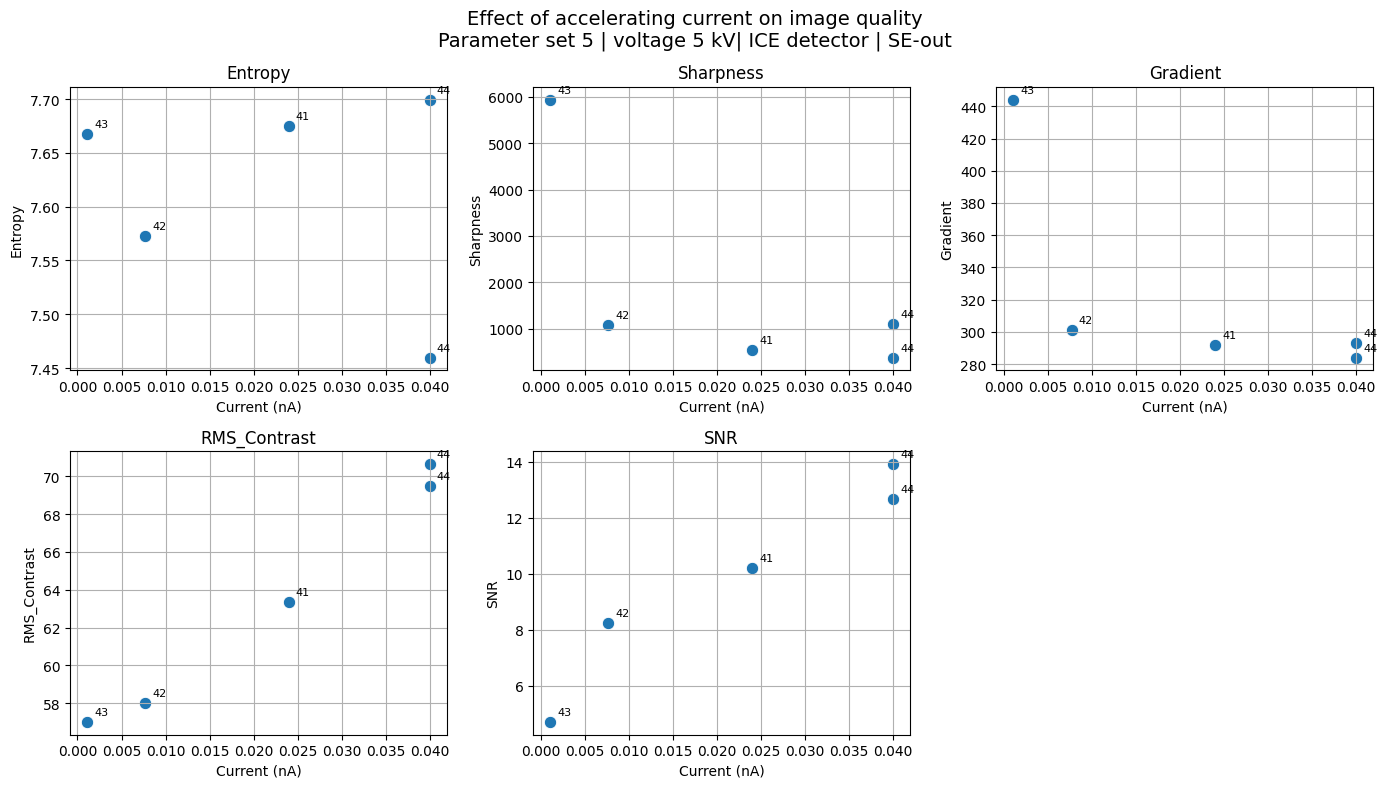

In [391]:
# Select dataset
ps5 = results[
    (results["parameter_set"] == 5)
]


metrics = [
    "Entropy",
    "Sharpness",
    "Gradient",
    "RMS_Contrast",
    "SNR"
]


# Create 2 rows, 3 columns
fig, axes = plt.subplots(
    2,
    3,
    figsize=(14, 8),
    sharex=False
)

# Flatten axes array for easy looping
axes = axes.flatten()


for ax, metric in zip(axes, metrics):

    sns.scatterplot(
        data=ps5,
        x="current_nA",
        y=metric,
        ax=ax,
        s=80,
    )

    imageID = 1  # Set to a specific image ID to annotate points, or None to skip annotation

    if imageID is not None:
        # ===== ADD THIS PART HERE =====
        for _, row in ps5.iterrows():
            ax.annotate(
                row["image_id"],                  # label text
                (row["current_nA"], row[metric]), # point location
                xytext=(5, 5),                    # offset from point
                textcoords="offset points",
                fontsize=8
            )
        # ==============================

    ax.set_title(metric)
    ax.set_xlabel("Current (nA)")
    ax.grid(True)


# Remove unused sixth plot
axes[-1].axis("off")


fig.suptitle(
    "Effect of accelerating current on image quality\n"
    "Parameter set 5 | voltage 5 kV| ICE detector | SE-out",
    fontsize=14
)

plt.tight_layout()

plt.show()

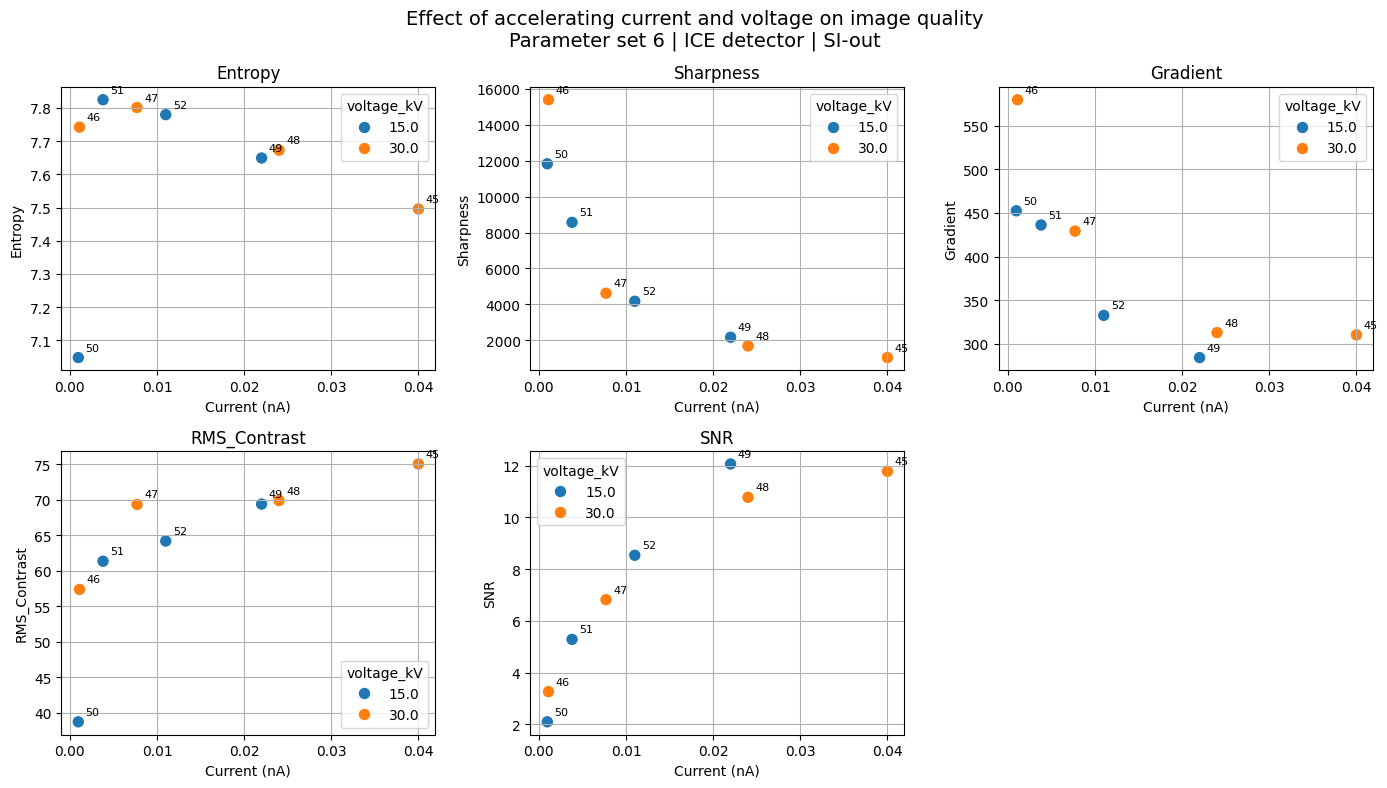

In [392]:
# Select dataset
ps6 = results[
    (results["parameter_set"] == 6)
]


metrics = [
    "Entropy",
    "Sharpness",
    "Gradient",
    "RMS_Contrast",
    "SNR"
]


# Create 2 rows, 3 columns
fig, axes = plt.subplots(
    2,
    3,
    figsize=(14, 8),
    sharex=False
)

# Flatten axes array for easy looping
axes = axes.flatten()


for ax, metric in zip(axes, metrics):

    sns.scatterplot(
        data=ps6,
        x="current_nA",
        y=metric,
        ax=ax,
        s=80,
        hue="voltage_kV",
        palette="tab10"
    )

    imageID = 1  # Set to a specific image ID to annotate points, or None to skip annotation
    
    if imageID is not None:
        # ===== ADD THIS PART HERE =====
        for _, row in ps6.iterrows():
            ax.annotate(
                row["image_id"],                  # label text
                (row["current_nA"], row[metric]), # point location
                xytext=(5, 5),                    # offset from point
                textcoords="offset points",
                fontsize=8
            )
        # ==============================

    ax.set_title(metric)
    ax.set_xlabel("Current (nA)")
    ax.grid(True)


# Remove unused sixth plot
axes[-1].axis("off")


fig.suptitle(
    "Effect of accelerating current and voltage on image quality\n"
    "Parameter set 6 | ICE detector | SI-out",
    fontsize=14
)

plt.tight_layout()

plt.show()

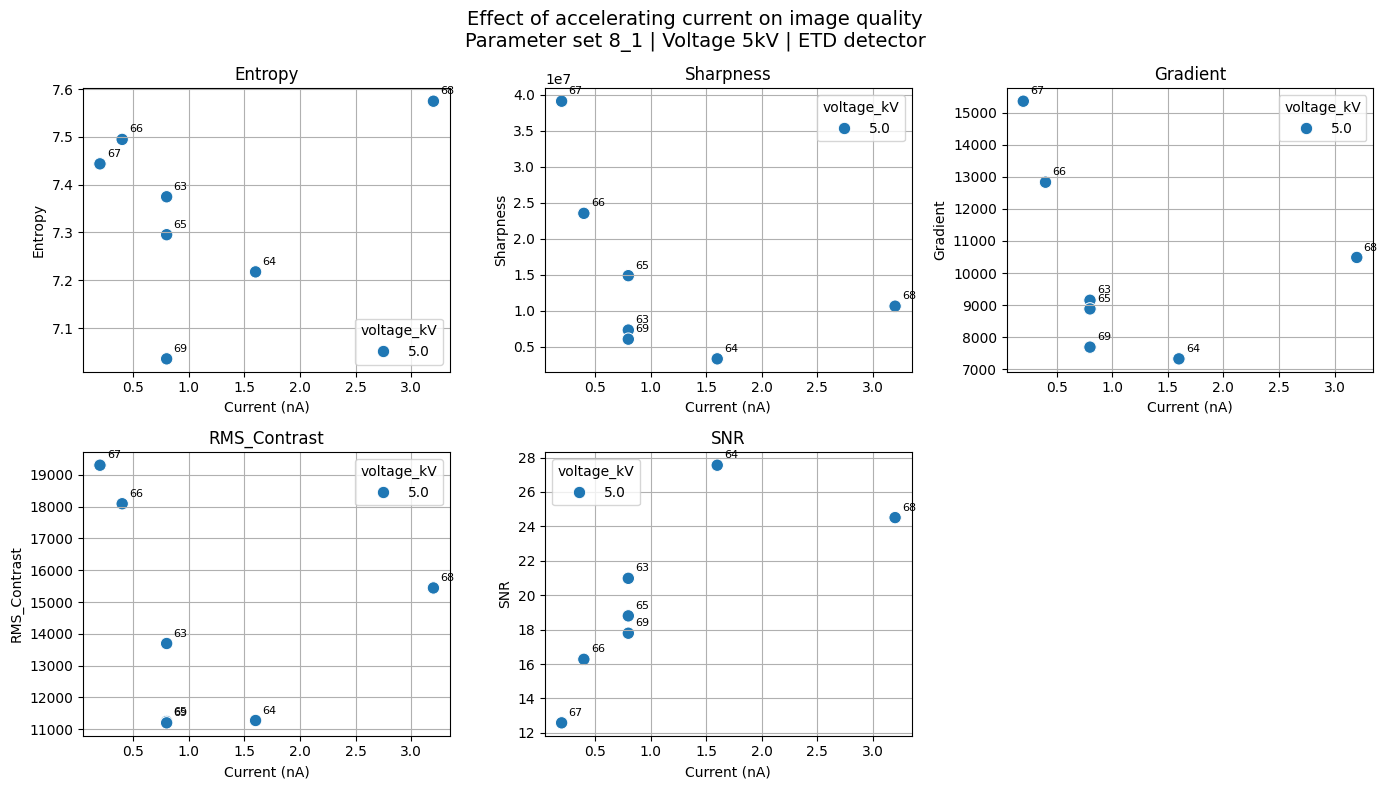

In [398]:
# Select dataset
ps8_1 = results[
    (results["parameter_set"] == 8) & 
    (results["voltage_kV"] == 5)
]


metrics = [
    "Entropy",
    "Sharpness",
    "Gradient",
    "RMS_Contrast",
    "SNR"
]


# Create 2 rows, 3 columns
fig, axes = plt.subplots(
    2,
    3,
    figsize=(14, 8),
    sharex=False
)

# Flatten axes array for easy looping
axes = axes.flatten()


for ax, metric in zip(axes, metrics):

    sns.scatterplot(
        data=ps8_1,
        x="current_nA",
        y=metric,
        ax=ax,
        s=80,
        hue="voltage_kV",
        palette="tab10"
    )

    imageID = 1  # Set to a specific image ID to annotate points, or None to skip annotation
    
    if imageID is not None:
        # ===== ADD THIS PART HERE =====
        for _, row in ps8_1.iterrows():
            ax.annotate(
                row["image_id"],                  # label text
                (row["current_nA"], row[metric]), # point location
                xytext=(5, 5),                    # offset from point
                textcoords="offset points",
                fontsize=8
            )
        # ==============================

    ax.set_title(metric)
    ax.set_xlabel("Current (nA)")
    ax.grid(True)


# Remove unused sixth plot
axes[-1].axis("off")


fig.suptitle(
    "Effect of accelerating current on image quality\n"
    "Parameter set 8_1 | Voltage 5kV | ETD detector",
    fontsize=14
)

plt.tight_layout()

plt.show()

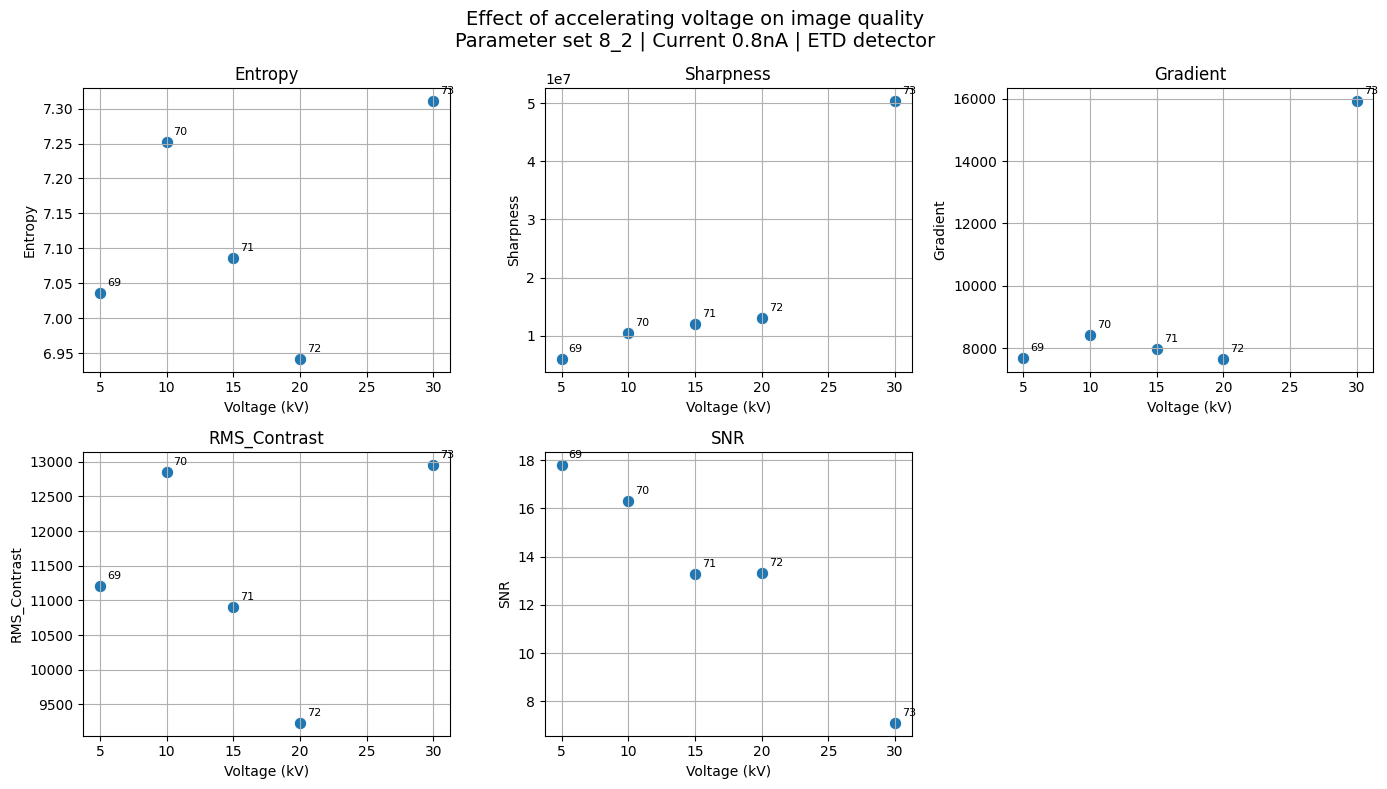

In [400]:
# Select dataset
ps8_2 = results[
    (results["parameter_set"] == 8) &
    (results["current_nA"] == 0.8) &
    (results["image_id"].between(69, 73))
]


metrics = [
    "Entropy",
    "Sharpness",
    "Gradient",
    "RMS_Contrast",
    "SNR"
]


# Create 2 rows, 3 columns
fig, axes = plt.subplots(
    2,
    3,
    figsize=(14, 8),
    sharex=False
)

# Flatten axes array for easy looping
axes = axes.flatten()


for ax, metric in zip(axes, metrics):

    sns.scatterplot(
        data=ps8_2,
        x="voltage_kV",
        y=metric,
        ax=ax,
        s=80,
    )

    imageID = 1  # Set to a specific image ID to annotate points, or None to skip annotation
    
    if imageID is not None:
        # ===== ADD THIS PART HERE =====
        for _, row in ps8_2.iterrows():
            ax.annotate(
                row["image_id"],                  # label text
                (row["voltage_kV"], row[metric]), # point location
                xytext=(5, 5),                    # offset from point
                textcoords="offset points",
                fontsize=8
            )
        # ==============================

    ax.set_title(metric)
    ax.set_xlabel("Voltage (kV)")
    ax.grid(True)


# Remove unused sixth plot
axes[-1].axis("off")


fig.suptitle(
    "Effect of accelerating voltage on image quality\n"
    "Parameter set 8_2 | Current 0.8nA | ETD detector",
    fontsize=14
)

plt.tight_layout()

plt.show()

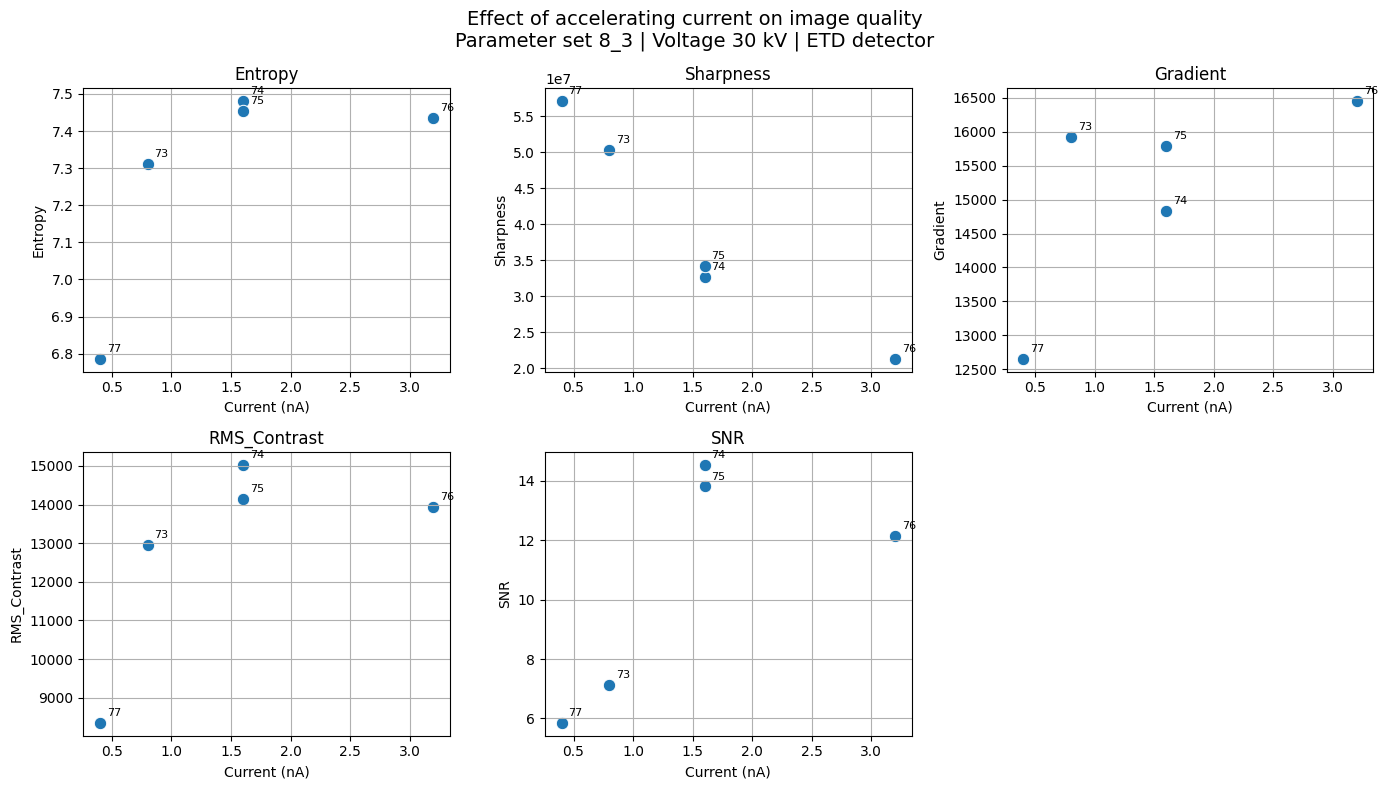

In [401]:
# Select dataset
ps8_3 = results[
    (results["parameter_set"] == 8) &
    (results["voltage_kV"] == 30) &
    (results["image_id"].between(73, 77))
]


metrics = [
    "Entropy",
    "Sharpness",
    "Gradient",
    "RMS_Contrast",
    "SNR"
]


# Create 2 rows, 3 columns
fig, axes = plt.subplots(
    2,
    3,
    figsize=(14, 8),
    sharex=False
)

# Flatten axes array for easy looping
axes = axes.flatten()


for ax, metric in zip(axes, metrics):

    sns.scatterplot(
        data=ps8_3,
        x="current_nA",
        y=metric,
        ax=ax,
        s=80,
    )

    imageID = 1  # Set to a specific image ID to annotate points, or None to skip annotation
    
    if imageID is not None:
        # ===== ADD THIS PART HERE =====
        for _, row in ps8_3.iterrows():
            ax.annotate(
                row["image_id"],                  # label text
                (row["current_nA"], row[metric]), # point location
                xytext=(5, 5),                    # offset from point
                textcoords="offset points",
                fontsize=8
            )
        # ==============================

    ax.set_title(metric)
    ax.set_xlabel("Current (nA)")
    ax.grid(True)


# Remove unused sixth plot
axes[-1].axis("off")


fig.suptitle(
    "Effect of accelerating current on image quality\n"
    "Parameter set 8_3 | Voltage 30 kV | ETD detector",
    fontsize=14
)

plt.tight_layout()

plt.show()

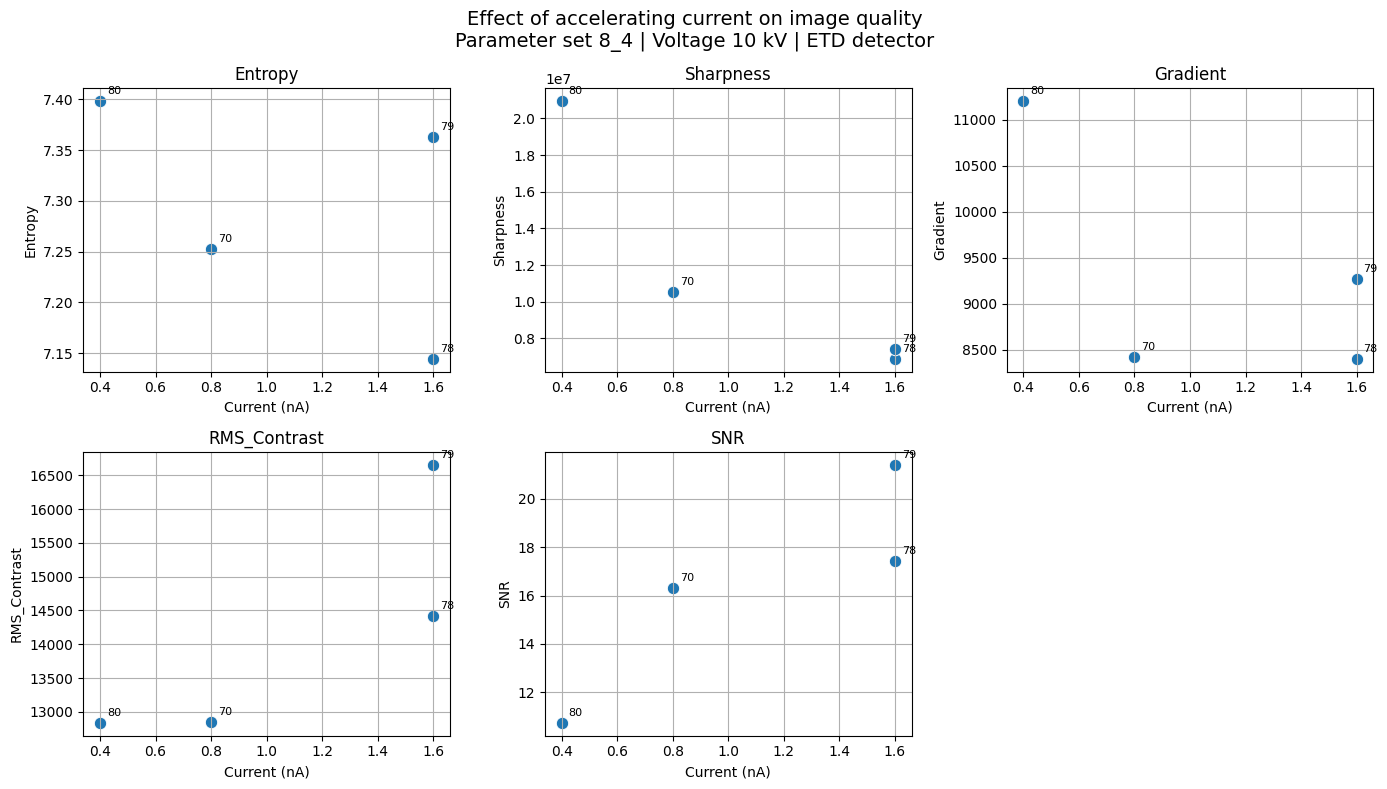

In [402]:
# Select dataset
ps8_4 = results[
    (results["parameter_set"] == 8) &
    (results["voltage_kV"] == 10) ]


metrics = [
    "Entropy",
    "Sharpness",
    "Gradient",
    "RMS_Contrast",
    "SNR"
]


# Create 2 rows, 3 columns
fig, axes = plt.subplots(
    2,
    3,
    figsize=(14, 8),
    sharex=False
)

# Flatten axes array for easy looping
axes = axes.flatten()


for ax, metric in zip(axes, metrics):

    sns.scatterplot(
        data=ps8_4,
        x="current_nA",
        y=metric,
        ax=ax,
        s=80,
    )

    imageID = 1  # Set to a specific image ID to annotate points, or None to skip annotation
    
    if imageID is not None:
        # ===== ADD THIS PART HERE =====
        for _, row in ps8_4.iterrows():
            ax.annotate(
                row["image_id"],                  # label text
                (row["current_nA"], row[metric]), # point location
                xytext=(5, 5),                    # offset from point
                textcoords="offset points",
                fontsize=8
            )
        # ==============================

    ax.set_title(metric)
    ax.set_xlabel("Current (nA)")
    ax.grid(True)


# Remove unused sixth plot
axes[-1].axis("off")


fig.suptitle(
    "Effect of accelerating current on image quality\n"
    "Parameter set 8_4 | Voltage 10 kV | ETD detector",
    fontsize=14
)

plt.tight_layout()

plt.show()

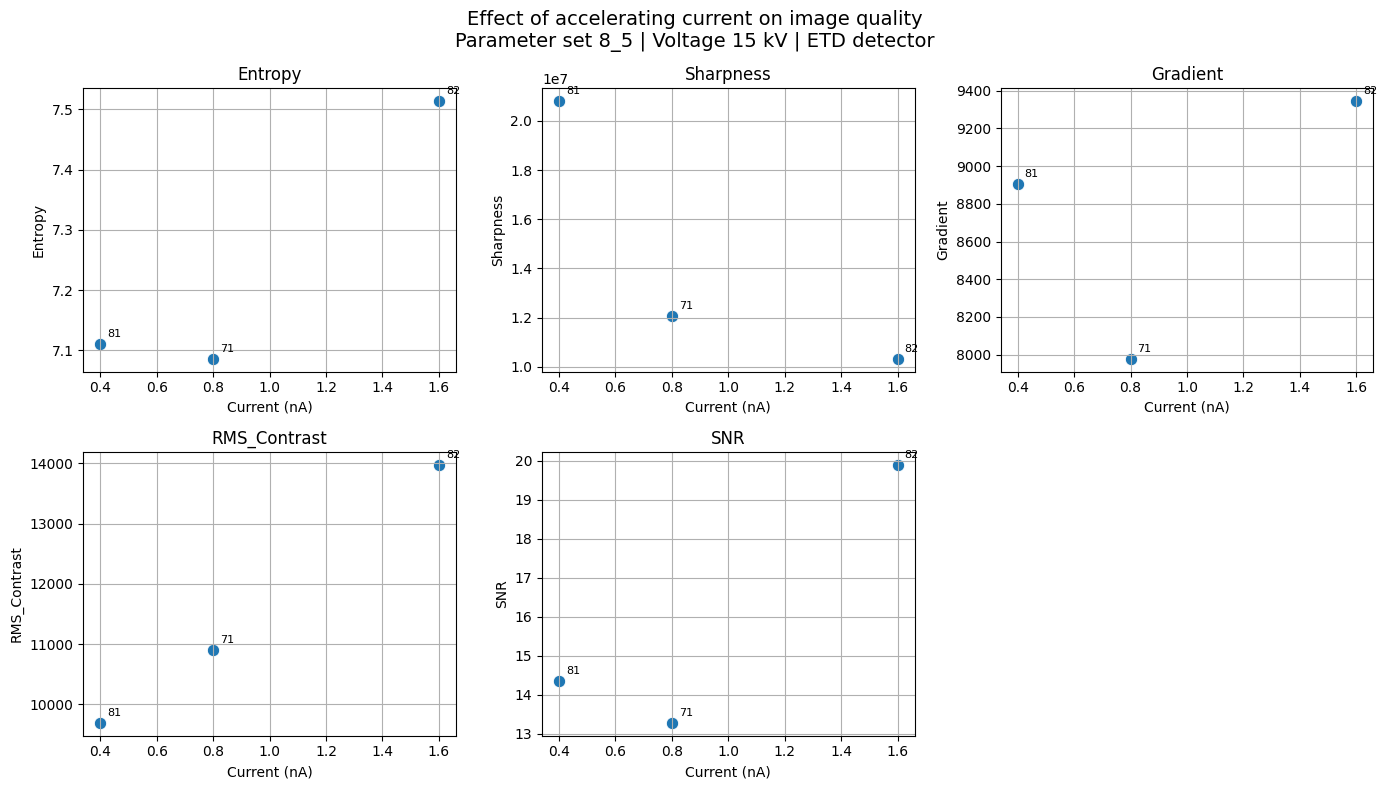

In [403]:
# Select dataset
ps8_5 = results[
    (results["parameter_set"] == 8) &
    (results["voltage_kV"] == 15) ]


metrics = [
    "Entropy",
    "Sharpness",
    "Gradient",
    "RMS_Contrast",
    "SNR"
]


# Create 2 rows, 3 columns
fig, axes = plt.subplots(
    2,
    3,
    figsize=(14, 8),
    sharex=False
)

# Flatten axes array for easy looping
axes = axes.flatten()


for ax, metric in zip(axes, metrics):

    sns.scatterplot(
        data=ps8_5,
        x="current_nA",
        y=metric,
        ax=ax,
        s=80,
    )

    imageID = 1  # Set to a specific image ID to annotate points, or None to skip annotation
    
    if imageID is not None:
        # ===== ADD THIS PART HERE =====
        for _, row in ps8_5.iterrows():
            ax.annotate(
                row["image_id"],                  # label text
                (row["current_nA"], row[metric]), # point location
                xytext=(5, 5),                    # offset from point
                textcoords="offset points",
                fontsize=8
            )
        # ==============================

    ax.set_title(metric)
    ax.set_xlabel("Current (nA)")
    ax.grid(True)


# Remove unused sixth plot
axes[-1].axis("off")


fig.suptitle(
    "Effect of accelerating current on image quality\n"
    "Parameter set 8_5 | Voltage 15 kV | ETD detector",
    fontsize=14
)

plt.tight_layout()

plt.show()

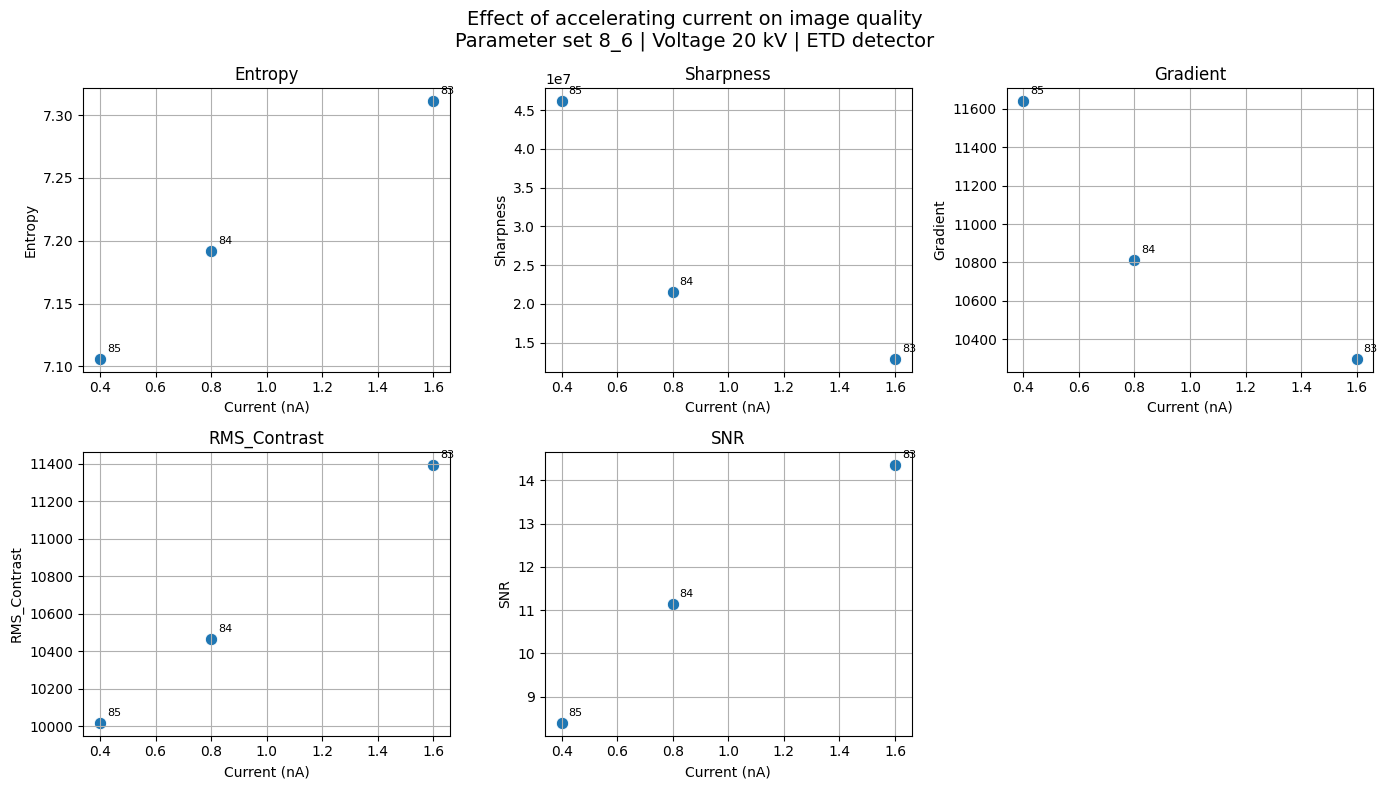

In [405]:
# Select dataset
ps8_6 = results[
    (results["parameter_set"] == 8) &
    (results["voltage_kV"] == 20) &
    (results["image_id"].between(83, 85))] 


metrics = [
    "Entropy",
    "Sharpness",
    "Gradient",
    "RMS_Contrast",
    "SNR"
]


# Create 2 rows, 3 columns
fig, axes = plt.subplots(
    2,
    3,
    figsize=(14, 8),
    sharex=False
)

# Flatten axes array for easy looping
axes = axes.flatten()


for ax, metric in zip(axes, metrics):

    sns.scatterplot(
        data=ps8_6,
        x="current_nA",
        y=metric,
        ax=ax,
        s=80,
    )

    imageID = 1  # Set to a specific image ID to annotate points, or None to skip annotation
    
    if imageID is not None:
        # ===== ADD THIS PART HERE =====
        for _, row in ps8_6.iterrows():
            ax.annotate(
                row["image_id"],                  # label text
                (row["current_nA"], row[metric]), # point location
                xytext=(5, 5),                    # offset from point
                textcoords="offset points",
                fontsize=8
            )
        # ==============================

    ax.set_title(metric)
    ax.set_xlabel("Current (nA)")
    ax.grid(True)


# Remove unused sixth plot
axes[-1].axis("off")


fig.suptitle(
    "Effect of accelerating current on image quality\n"
    "Parameter set 8_6 | Voltage 20 kV | ETD detector",
    fontsize=14
)

plt.tight_layout()

plt.show()

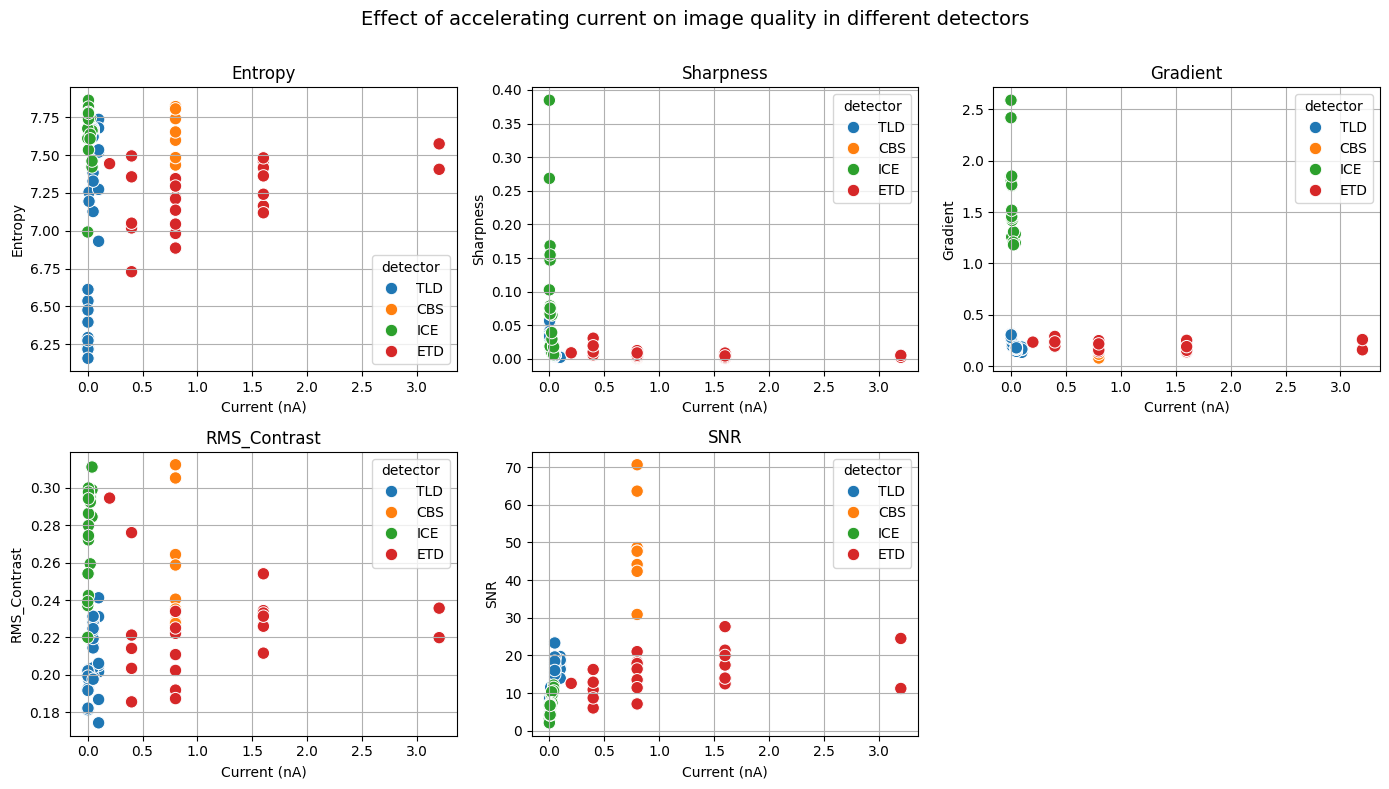

In [406]:
metrics = [
    "Entropy",
    "Sharpness",
    "Gradient",
    "RMS_Contrast",
    "SNR"
]


# Create 2 rows, 3 columns
fig, axes = plt.subplots(
    2,
    3,
    figsize=(14, 8),
    sharex=False
)

# Flatten axes array for easy looping
axes = axes.flatten()


for ax, metric in zip(axes, metrics):
    sns.scatterplot(
        data=results_normalised,
        x="current_nA",
        y=metric,
        hue="detector",
        ax=ax,
        s=80
    ) 

    ax.set_title(metric)
    ax.set_xlabel("Current (nA)")
    ax.grid(True)


# Remove unused sixth plot
axes[-1].axis("off")


fig.suptitle(
    "Effect of accelerating current on image quality in different detectors\n",
    fontsize=14
)

plt.tight_layout()

plt.show()

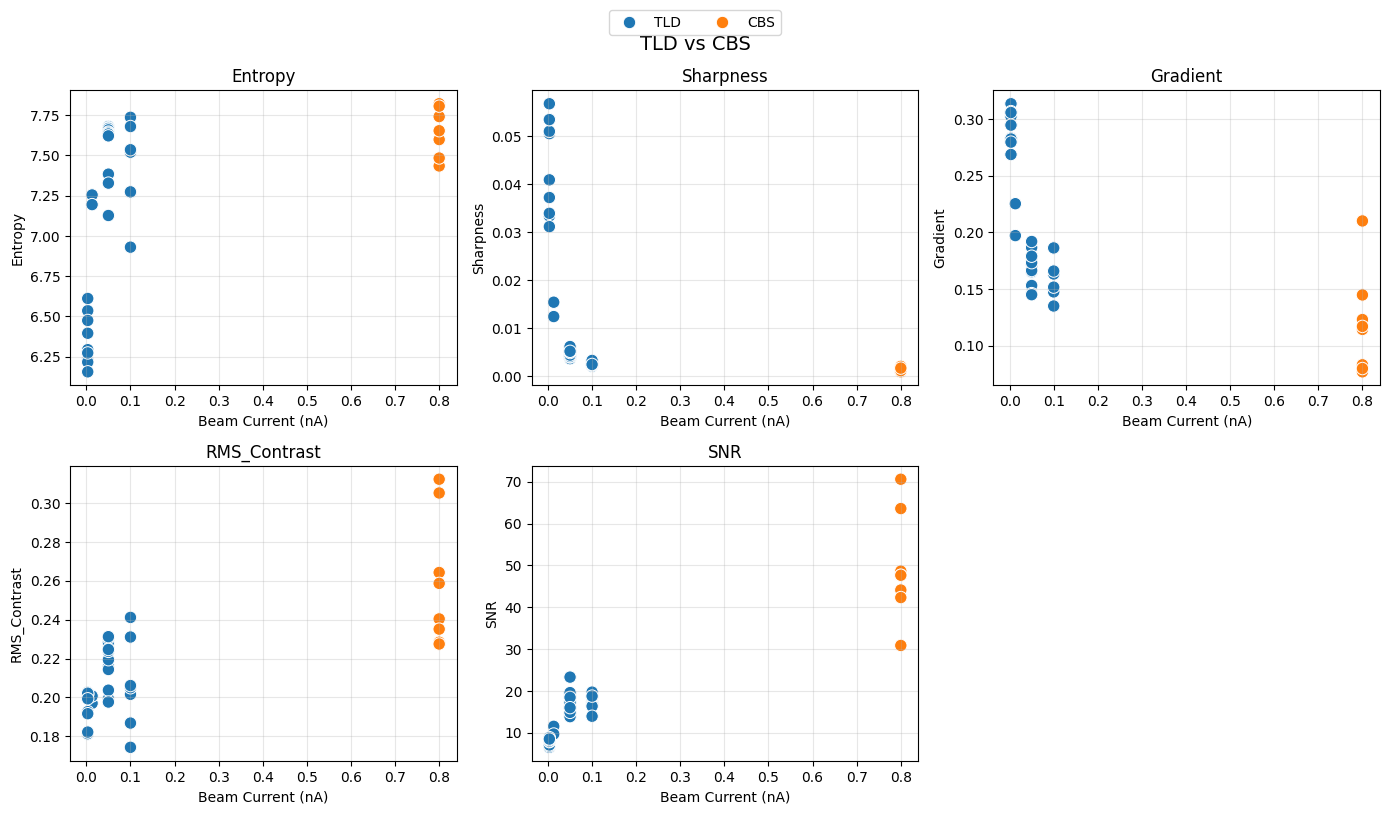

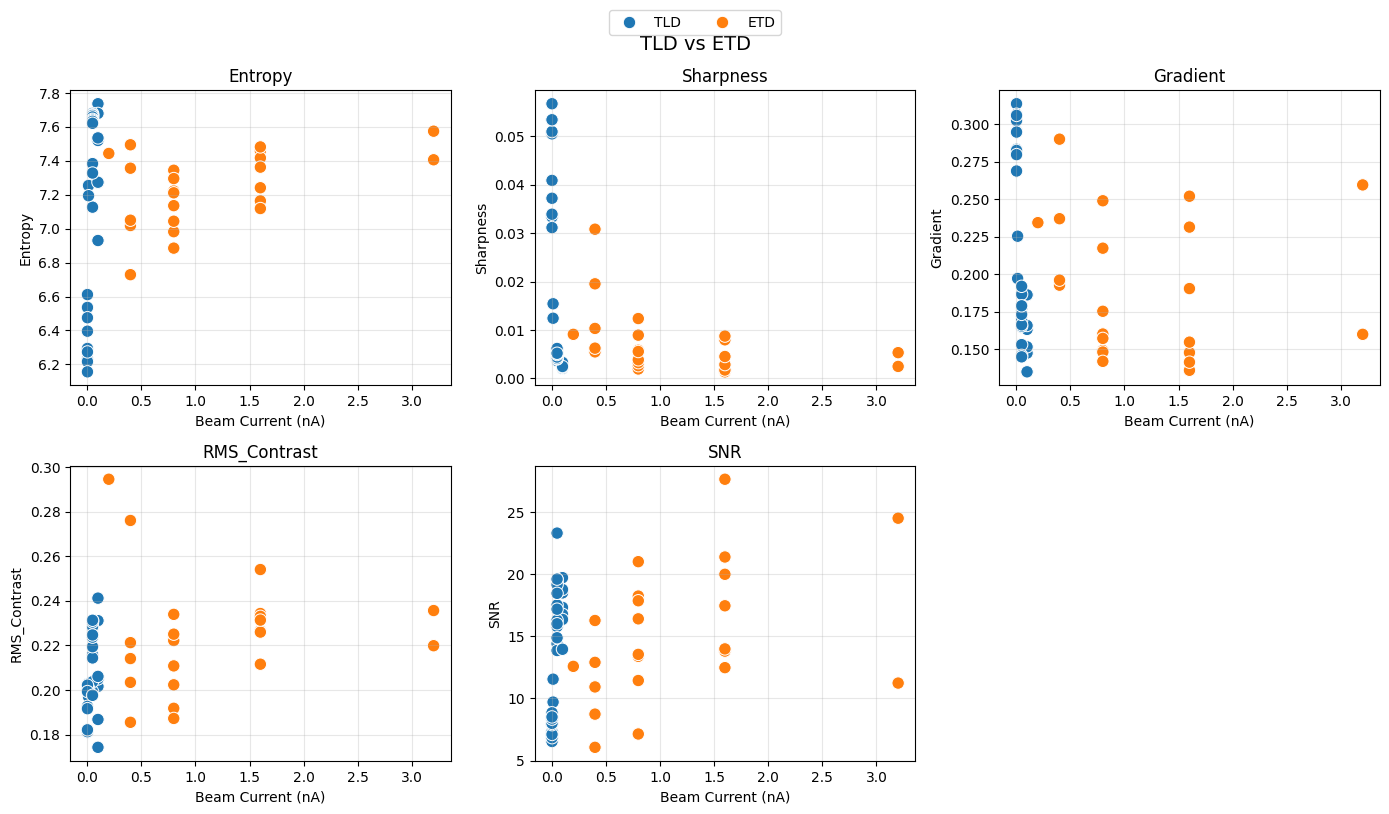

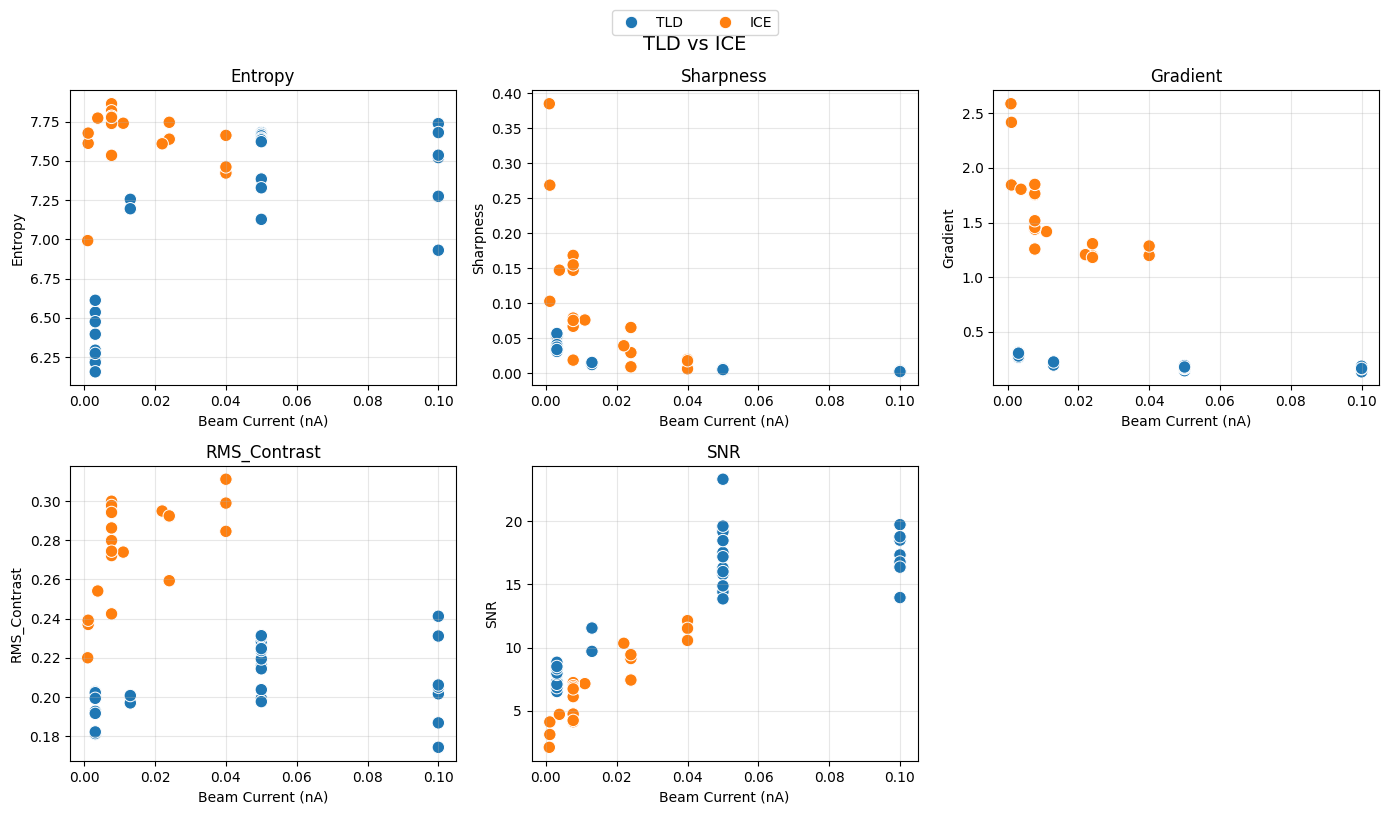

In [407]:
reference = "TLD"
comparisons = ["CBS", "ETD", "ICE"]

metrics = [
    "Entropy",
    "Sharpness",
    "Gradient",
    "RMS_Contrast",
    "SNR"
]

for detector in comparisons:

    subset = results_normalised[
        results_normalised["detector"].isin([reference, detector])
    ]

    fig, axes = plt.subplots(
        2,
        3,
        figsize=(14, 8),
        sharex=False
    )

    axes = axes.flatten()

    for ax, metric in zip(axes, metrics):

        sns.scatterplot(
            data=subset,
            x="current_nA",
            y=metric,
            hue="detector",
            ax=ax,
            s=80
        )

        ax.set_title(metric)
        ax.set_xlabel("Beam Current (nA)")
        ax.grid(alpha=0.3)

    # Remove unused subplot
    axes[-1].axis("off")

    # Keep only one legend
    handles, labels = axes[0].get_legend_handles_labels()

    for ax in axes[:-1]:
        if ax.get_legend() is not None:
            ax.get_legend().remove()

    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=2,
        bbox_to_anchor=(0.5, 1.02)
    )

    fig.suptitle(
        f"{reference} vs {detector}",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

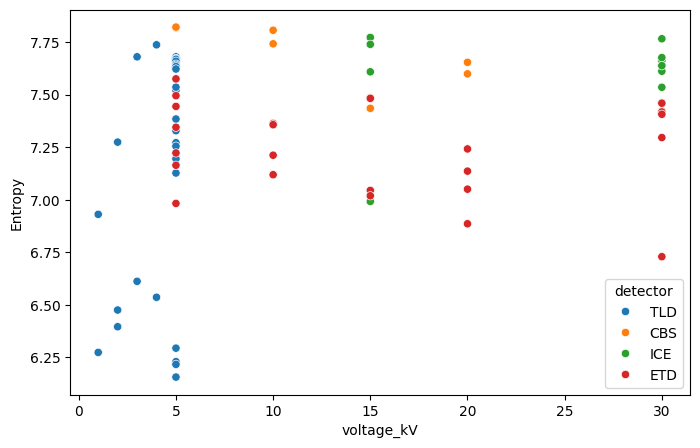

In [341]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=results_normalised,
    x="voltage_kV",
    y="Entropy",
    hue="detector"
)

plt.show()